In [2]:
using JuMP, Gurobi
using Clp

In [3]:
using Random, Distributions

In [4]:
using Combinatorics, Suppressor
using BenchmarkTools

In [5]:
all_costs = collect(permutations(1:4))
n = 4
B = 100

100

In [6]:
# charges = round.(rand(Normal(5, 2), n+1)) .* 10
charges = [60, 50, 40, 80, 50]

5-element Vector{Int64}:
 60
 50
 40
 80
 50

In [9]:
function solve_charge_rebalancing(B::Int, charges::Vector{Int}, costs::Vector{Int})
    # model = Model(Gurobi.Optimizer)
    model = Model(Clp.Optimizer)
    set_silent(model)
    set_string_names_on_creation(model, false)
    n = length(costs)
    @variable(model, x[1:n] ≥ 0)
    @constraint(model, [i=1:n], sum(x[j] for j in 1:i) ≥ sum(charges[j] for j in 1:(i+1)) - B)
    @constraint(model, [i=1:n], sum(x[j] for j in 1:i) ≤ sum(charges[j] for j in 1:i))
    @objective(model, Min, sum(x[i] * costs[i] for i in 1:n))
    optimize!(model)
    x_sol = value.(model[:x])
    return Int.(x_sol)
end

solve_charge_rebalancing (generic function with 1 method)

In [10]:
B = 100
charges = [60, 50, 40, 80, 50]
costs = [3, 2, 1, 4]
solve_charge_rebalancing(B, Int.(charges), Int.(costs))

In [29]:
costs = pop!(all_costs)
@show costs
lower_bounds = [
    max(sum(charges[j] for j in 1:(i+1)) - B, 0)
    for i in 1:n
];
upper_bounds = [
    sum(charges[j] for j in 1:i)
    for i in 1:n
];
[
    lower_bounds upper_bounds
]


costs = [4, 2, 1, 3]


4×2 Matrix{Float64}:
  10.0   60.0
  50.0  110.0
 130.0  150.0
 180.0  230.0

In [30]:
@time x_sol = solve_charge_rebalancing(B, Int.(charges), Int.(costs));
[
    lower_bounds cumsum(x_sol) upper_bounds
]

Set parameter Username
Academic license - for non-commercial use only - expires 2024-06-07
  0.020100 seconds (12.12 k allocations: 724.719 KiB, 83.64% compilation time)


4×3 Matrix{Float64}:
  10.0   10.0   60.0
  50.0   50.0  110.0
 130.0  150.0  150.0
 180.0  180.0  230.0

In [47]:
B

100

In [65]:
charges = Int.(charges)
costs = [20, 40, 10, 30]

4-element Vector{Int64}:
 20
 40
 10
 30

In [81]:
n = length(costs)
x_cumsum = zeros(Int, n)
lower_bounds = [
    sum(charges[j] for j in 1:(i+1)) - B
    for i in 1:n
]
upper_bounds = [
    sum(charges[j] for j in 1:i)
    for i in 1:n
]
x_cumsum[end] = lower_bounds[end]
x_cumsum_filled = falses(n)

4-element BitVector:
 0
 0
 0
 0

In [82]:
[
    lower_bounds x_cumsum upper_bounds
]

4×3 Matrix{Int64}:
  10    0   60
  50    0  110
 130    0  150
 180  180  230

In [68]:
p = sortperm(costs)
@show costs
;

costs = [20, 40, 10, 30]


In [83]:
for i in 1:n 
    if p[i] != 1
        if !x_cumsum_filled[p[i]-1]
            x_cumsum[p[i]-1] = lower_bounds[p[i]-1]
            x_cumsum_filled[p[i]-1] = true
            if p[i] > 2
                upper_bounds[p[i]-2] = min(upper_bounds[p[i]-2], lower_bounds[p[i]-1])
            end
        end
    end
    if p[i] != n
        if !x_cumsum_filled[p[i]]
            x_cumsum[p[i]] = upper_bounds[p[i]]
            x_cumsum_filled[p[i]] = true
            if p[i] < n-1
                lower_bounds[p[i]+1] = max(lower_bounds[p[i]+1], upper_bounds[p[i]])
            end
        end
    end
    println(x_cumsum)
end

[0, 50, 150, 180]
[50, 50, 150, 180]
[50, 50, 150, 180]
[50, 50, 150, 180]


In [13]:
function solve_charge_rebalancing_analytic(B::Int, charges::Vector{Int}, costs::Vector{Int})
    n = length(costs)
    x_cumsum = zeros(Int, n)
    x_cumsum_filled = falses(n)
    lower_bounds = [
        sum(charges[j] for j in 1:(i+1)) - B
        for i in 1:n
    ]
    upper_bounds = [
        sum(charges[j] for j in 1:i)
        for i in 1:n
    ]
    x_cumsum[end] = lower_bounds[end]
    p = sortperm(costs)
    for i in 1:n 
        if p[i] != 1
            if !x_cumsum_filled[p[i]-1]
                x_cumsum[p[i]-1] = lower_bounds[p[i]-1]
                x_cumsum_filled[p[i]-1] = true
                if p[i] > 2
                    upper_bounds[p[i]-2] = min(upper_bounds[p[i]-2], lower_bounds[p[i]-1])
                end
            end
        end
        if p[i] != n
            if !x_cumsum_filled[p[i]]
                x_cumsum[p[i]] = upper_bounds[p[i]]
                x_cumsum_filled[p[i]] = true
                if p[i] < n-1
                    lower_bounds[p[i]+1] = max(lower_bounds[p[i]+1], upper_bounds[p[i]])
                end
            end
        end
    end
    pushfirst!(x_cumsum, 0)
    x_sol = x_cumsum[2:end] - x_cumsum[1:end-1]
    return x_sol
end

solve_charge_rebalancing_analytic (generic function with 1 method)

In [84]:
@time x_sol = solve_charge_rebalancing_analytic(B, Int.(charges), Int.(costs));
[
    lower_bounds cumsum(x_sol) upper_bounds
]

  0.000111 seconds (13 allocations: 1008 bytes)


4×3 Matrix{Int64}:
  10   50   50
  50   50  110
 130  150  150
 180  180  230

In [71]:
function solve_charge_rebalancing_recursive(
    B::Int,
    m::Int,
    charges::Vector{Int},
    costs::Vector{Int},
)
    if m ≤ 1
        return Int[]
    end
    if sum(charges) ≤ B
        return zeros(Int, m - 1)
    end

    i = m - argmin(reverse(costs))
    val = min(
        sum(charges) - B, # l_{m-1}
        sum(charges[1:i]), # u_i
        sum(charges[i+1:end]),
        B,
    )
    return vcat(
        solve_charge_rebalancing_recursive(B, i, charges[1:i], costs[1:i-1]),
        [val],
        solve_charge_rebalancing_recursive(B, m-i, charges[i+1:end], costs[i+1:end]),
    )
end

solve_charge_rebalancing_recursive (generic function with 3 methods)

In [53]:
@btime solve_charge_rebalancing_recursive(10, [5, 3, 6, 9, 2, 4], [3, 5, 1,3, 2])

  925.265 ns (43 allocations: 3.05 KiB)


5-element Vector{Int64}:
  4
  0
 10
  1
  4

In [68]:
sum([5, 3, 6, 9, 2, 4, 3, 6])

38

In [69]:
@btime solve_charge_rebalancing_recursive(10, 8, [5, 3, 6, 9, 2, 4, 3, 6], [3, 5, 1, 2, 3, 4, 5])

  1.137 μs (53 allocations: 4.00 KiB)


7-element Vector{Int64}:
  4
  0
 10
  9
  2
  3
  0

In [70]:
@btime solve_charge_rebalancing_recursive(10, 8, 38, [5, 3, 6, 9, 2, 4, 3, 6], [3, 5, 1, 2, 3, 4, 5])

  1.154 μs (53 allocations: 4.00 KiB)


7-element Vector{Int64}:
  4
  0
 10
  9
  2
  3
  0

In [65]:
@btime solve_charge_rebalancing_recursive_main(10, [5, 3, 6, 9, 2, 4, 3, 6], [3, 5, 1, 2, 3, 4, 5])

  1.217 μs (55 allocations: 4.23 KiB)


7-element Vector{Int64}:
  4
  0
 10
  9
  2
  3
  0

In [92]:
using CairoMakie
using Makie.GeometryBasics

In [435]:
B = 100

100

In [441]:
m = 15

15

In [508]:
charges = Int.(round.(rand(Distributions.Normal(10, 4), m)) .* 5)

15-element Vector{Int64}:
 55
 40
 40
 55
 40
 35
 30
 50
 65
 20
 50
 50
 60
 45
 50

In [498]:
costs = Int.(round.(rand(Distributions.Normal(10, 4), m-1)) .* 5)
scosts = sort(unique(costs))
cost_ranks = Int[findfirst(x -> x == i, scosts) for i in costs]

14-element Vector{Int64}:
 9
 4
 6
 5
 5
 1
 7
 8
 2
 3
 6
 5
 4
 3

In [506]:
f = plot_binary_sorted_tree(costs; radius = 0.4, fontsize = 13, omega_fontsize = 13, omega_textoffset = 0.7, append = true)
save("example_tree.png", f)

CairoMakie.Screen{IMAGE}


In [467]:
function plot_charge_diagram(
    B::Int,
    charges::Vector{Int},
    ;
    costs::Union{Nothing, Vector{Int}} = nothing,
    sol::Union{Nothing, Vector{Int}} = nothing,
)

    xcum = vcat([0], cumsum(charges))
    xmin = xcum[1:end-1]
    xmax = xcum[2:end]
    ymin = max.(cumsum(charges) .- B, 0)
    ymax = vcat([0], cumsum(charges)[1:end-1])
    ymax = min.(ymax, ymin[end])

    if !isnothing(sol)
        ycum = vcat([0], cumsum(sol))
        ymin_sol = ycum[1:end-1]
        ymax_sol = ycum[2:end]
    end

    f = Figure(size = (600, 500))
    ax = Axis(
        f[1,1], 
        aspect = DataAspect(),
        xlabel = "Total charge used",
        ylabel = "Total amount recharged",
    )
    resize_to_layout!(f)
    hidedecorations!(ax, label = false, ticks = false, ticklabels = false)
    poly!(
        Point2f[
            (0, 0),
            (sum(charges), sum(charges)),
            (0, sum(charges)),
        ],
        color = :grey75,
        strokecolor = :grey75,
        strokewidth = 1,
    )
    poly!(
        Point2f[
            (B, 0),
            (sum(charges) + B, sum(charges)),
            (sum(charges) + B, 0),
        ],
        color = :grey75,
        strokecolor = :grey75,
        strokewidth = 1,
    )
    for i in 1:length(charges)
        # Plots horizontal segments
        scatterlines!([xmin[i], xmax[i]], [ymin[i], ymin[i]], color = :black, markersize = 8, markercolor = :black)
        scatterlines!([xmin[i], xmax[i]], [ymax[i], ymax[i]], color = :black, markersize = 8, markercolor = :black)
    end
    for i in 1:length(charges)-1
        # Plots vertical dotted lines
        scatterlines!([xmax[i], xmax[i]], [ymin[i], ymax[i+1]], color = :grey75, linestyle = :dot, linewidth = 1, markersize = 8, markercolor = :black)
        if !isnothing(costs)
            # Annotates charging station costs
            text!([xmax[i]], [xmax[i] + B / 8], text = "$(costs[i])", fontsize = 10, color = :black, align = (:center, :center))
        end
    end
    if !isnothing(sol)
        for i in 1:length(charges)
            # Plots horizontal segments (solution)
            scatterlines!([xmin[i], xmax[i]], [ycum[i], ycum[i]], color = :blue, linewidth = 1.5, markersize = 8, markercolor = :black)
        end
        for i in 1:length(charges)-1
            # Plots vertical lines (solution)
            scatterlines!([xmax[i], xmax[i]], [ymin_sol[i], ymax_sol[i]], color = :blue, linewidth = 1.5, markersize = 8, markercolor = :black)
        end
    end
    f
end

plot_charge_diagram (generic function with 1 method)

In [511]:
tau = solve_charge_rebalancing_recursive(B, charges[1:end-1], cost_ranks[1:end-1])

13-element Vector{Int64}:
   0
  95
   0
  35
  35
 100
  30
  15
 100
  20
   0
  60
  45

In [507]:
charges

15-element Vector{Int64}:
  65
  35
 115
  55
  90
  55
  55
  30
  65
   5
  25
  25
  50
  15
  30

In [509]:
f = plot_charge_diagram(
    B, charges[1:end-1]; 
    # costs = cost_ranks, 
    # sol = tau,
)
save("example.png", f)

CairoMakie.Screen{IMAGE}


In [512]:
f = plot_charge_diagram(
    B, charges[1:end-1]; 
    costs = cost_ranks[1:end-1], 
    sol = tau,
)
save("example_sol.png", f)

CairoMakie.Screen{IMAGE}


In [20]:
function argmin_end(arr::Vector{Int})
    return length(arr) - argmin(reverse(arr)) + 1
end

argmin_end (generic function with 1 method)

In [18]:
function yield_arcs(offset::Int, arr::Vector{Int}, topright_arc::Bool)
    if length(arr) ≤ 1
        return Tuple{Int, Int, Bool}[]
    end
    res = Tuple{Int, Int, Bool}[]
    l = argmin_end(arr)
    if l-1 ≥ 1
        l_left = argmin_end(arr[1:l-1])
        push!(res, (l + offset, l_left + offset, false))
        append!(res, yield_arcs(offset, arr[1:l-1], false))
    end
    if l+1 ≤ length(arr)
        l_right = argmin_end(arr[l+1:end])
        push!(res, (l+ offset, l + l_right + offset, topright_arc))
        append!(res, yield_arcs(offset + l, arr[l+1:end], topright_arc))
    end
    return res
end

yield_arcs (generic function with 1 method)

In [16]:
function plot_binary_sorted_tree(
    arr::Vector{Int}; 
    append::Bool = false,
    radius::Float64 = 0.2, 
    fontsize::Int = 15,
    omega_textoffset::Float64 = 0.5,
    omega_fontsize::Int = fontsize,
)

    function compute_arc_coords(
        src::Int, dst::Int,
    )            
        src_x = node_x[src]
        src_y = node_y[src]
        dst_x = node_x[dst]
        dst_y = node_y[dst]
        hyp = sqrt((dst_x - src_x)^2 + (dst_y - src_y)^2)
        delta_x = (dst_x - src_x) * radius / hyp
        delta_y = (dst_y - src_y) * radius / hyp
        head_x = src_x + delta_x
        head_y = src_y + delta_y
        tail_x = dst_x - delta_x
        tail_y = dst_y - delta_y
        return (head_x, head_y, tail_x - head_x, tail_y - head_y)
    end

    sarr = sort(unique(arr))
    ranks = Int[findfirst(x -> x == i, sarr) for i in arr]

    node_x = 1:length(ranks)
    D = maximum(ranks)
    node_y = -ranks

    f = Figure()
    ax = Axis(
        f[1,1],
        aspect = DataAspect(),
        limits = (nothing, nothing, nothing, nothing),
        yticks = (-1:-1:-D, ["d = $d" for d in 1:D]),
        yticklabelalign = (:right, :center),
    )
    # colsize!(f.layout, 1, Makie.Relative(1))
    resize_to_layout!(f)
    # hidedecorations!(ax, label = false, yticks = false)
    hidexdecorations!(ax)
    hideydecorations!(ax, label = false, ticks = false, ticklabels = false)
    # for d in 1:D
    #     text!([-1], [-d], text = "d = $d", fontsize = fontsize, color = :black, align = (:left, :center))
    # end
    colors = [:grey75 for i in 1:length(ranks)]
    omega_nodes = Int[]

    # Draw arcs
    if append
        arcs_without = yield_arcs(0, ranks[1:end-1], true)
        arcs_with = yield_arcs(0, ranks, true)
        for arc in intersect(arcs_without, arcs_with)
            (x, y, u, v) = compute_arc_coords(arc[1], arc[2])
            arrows!([x], [y], [u], [v], align = :origin)
            if arc[3]
                push!(omega_nodes, arc[1])
                push!(omega_nodes, arc[2])
            end
        end
        for arc in setdiff(arcs_without, arcs_with)
            (x, y, u, v) = compute_arc_coords(arc[1], arc[2])
            arrows!([x], [y], [u], [v], align = :origin, linestyle = :dot, linecolor = :grey50)
            if arc[3]
                push!(omega_nodes, arc[1])
                push!(omega_nodes, arc[2])
            end
        end
        for arc in setdiff(arcs_with, arcs_without)
            (x, y, u, v) = compute_arc_coords(arc[1], arc[2])
            arrows!([x], [y], [u], [v], align = :origin, linewidth = 2)
        end
        push!(omega_nodes, length(ranks) - 1)
        sort!(unique!(omega_nodes))
        colors[omega_nodes] .= :lightgoldenrod
        colors[end] = :lightskyblue
    else
        for arc in yield_arcs(0, ranks, true)
            (x, y, u, v) = compute_arc_coords(arc[1], arc[2])
            arrows!([x], [y], [u], [v], align = :origin)
            if arc[3]
                push!(omega_nodes, arc[1])
                push!(omega_nodes, arc[2])
            end
        end
        push!(omega_nodes, length(ranks))
        sort!(unique!(omega_nodes))
        colors[omega_nodes] .= :lightgoldenrod
    end
    
    # Draw circles
    poly!(
        [Circle(Point2f(x, y), radius) for (x, y) in zip(node_x, node_y)],
        color = colors,
        strokecolor = :black,
        strokewidth = 2,
    )
    # Draw circle text
    for i in 1:length(ranks)
        text!(
            [node_x[i]], 
            [node_y[i]], 
            text = "$(i)", 
            fontsize = fontsize, 
            color = :black, 
            align = (:center, :center),
        )
    end
    # Draw omega annotations
    for i in findall(x -> x == :lightgoldenrod, colors)
        text!(
            [i],
            [-ranks[i] + omega_textoffset],
            text = L"ω_{%$(ranks[i])}", 
            fontsize = omega_fontsize, 
            color = :black, 
            align = (:center, :center),
        )
    end
    return f
end

plot_binary_sorted_tree (generic function with 1 method)

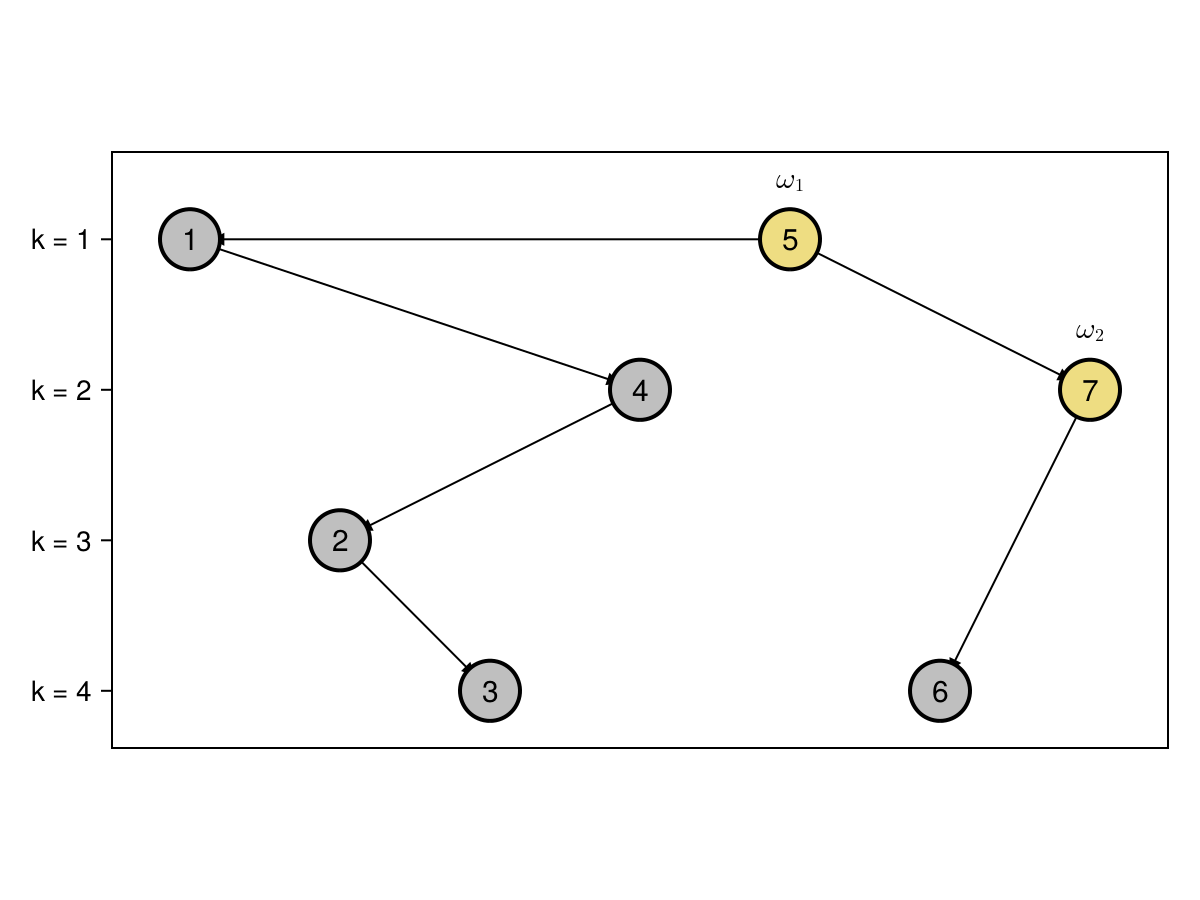

In [475]:
plot_binary_sorted_tree([3, 6, 12, 4, 3, 12, 4], omega_textoffset = 0.4)

Relative(1.0f0)

In [13]:
using Random, Distributions

In [73]:
arr = Int.(round.(rand(Distributions.Normal(10, 4), 15)) .* 5)

15-element Vector{Int64}:
  75
  40
  60
  15
  55
  70
  45
  50
  65
  90
  75
  50
  65
 110
  60

In [75]:
f = plot_binary_sorted_tree(arr; append = true, radius = 0.4, fontsize = 13, omega_fontsize = 13, omega_textoffset = 0.8)
save("example_tree.png", f)

CairoMakie.Screen{IMAGE}


## Reduced cost increase graphs

In [2]:
using CairoMakie

In [3]:
using Plots 

In [4]:
function get_points_of_piecewise_linear(
    coeffs::Vector{Float64},
    intercepts::Vector{Float64},
)
    @assert issorted(intercepts)
    @assert all(intercepts .≥ 0)
    points = [(0.0, 0.0)]
    for (intercept, coeff) in zip(intercepts, coeffs)
        old_x, old_y = points[end]
        push!(points, (intercept, old_y + (coeff * (intercept - old_x))))
    end
    return points

end

get_points_of_piecewise_linear (generic function with 1 method)

In [5]:
coeffs = [1.0, 1.5, 2.5, 4.0]
intercepts1 = [3.0, 5.0, 7.0, 8.0]
intercepts2 = [2.0, 4.5, 6.0, 8.0]
positions1 = get_points_of_piecewise_linear(coeffs, intercepts1)
positions2 = get_points_of_piecewise_linear(coeffs, intercepts2)

5-element Vector{Tuple{Float64, Float64}}:
 (0.0, 0.0)
 (2.0, 2.0)
 (4.5, 5.75)
 (6.0, 9.5)
 (8.0, 17.5)

In [6]:
xticklocs = vcat(0.0, sort(unique(union(intercepts1[1:end-1], intercepts2[1:end-1]))))
xticklabels = vcat(["0"], [
    !isnothing(findfirst(isequal(i), intercepts1)) ? L"Z_{%$(findfirst(isequal(i), intercepts1))}^1" : !isnothing(findfirst(isequal(i), intercepts2)) ? L"Z_{%$(findfirst(isequal(i), intercepts2))}^2" : "" 
    for i in xticklocs[2:end]
])

7-element Vector{AbstractString}:
 "0"
 L"$Z_{1}^2$"
 L"$Z_{1}^1$"
 L"$Z_{2}^2$"
 L"$Z_{2}^1$"
 L"$Z_{3}^2$"
 L"$Z_{3}^1$"

In [8]:
L"g(\tau; \{ Z^1_d \}_{d\in[f-1]})"

L"$g(\tau; \{ Z^1_d \}_{d\in[f-1]})$"

In [9]:
L"g(\tau; Z^1_1, \dots, Z^1_{f-1})"

L"$g(\tau; Z^1_1, \dots, Z^1_{f-1})$"

In [10]:
positions2

5-element Vector{Tuple{Float64, Float64}}:
 (0.0, 0.0)
 (2.0, 2.0)
 (4.5, 5.75)
 (6.0, 9.5)
 (8.0, 17.5)

In [11]:
f = Figure()
ax = Axis(
    f[1, 1],
    limits = (0, nothing, 0, nothing),
    xticks = (xticklocs, xticklabels),
    yticks = ([0], ["0"]),
)
scatterlines!(positions1, label = L"g(\tau; Z^1_1, \dots, Z^1_{f-1})")
scatterlines!(positions2, label = L"g(\tau; Z^2_1, \dots, Z^2_{f-1})")
Legend(f[1, 2], ax)
for (i, (x, y), (old_x, old_y), coeff) in zip(1:length(positions2), positions2[2:end], positions2, coeffs)
    offset = coeff / 8
    xpos = (0.4 * x + 0.6 * old_x)
    ypos = (y + old_y) / 2 + offset
    text!(xpos, ypos, text = L"\delta_{%$i}")
end
# hidedecorations!(ax, label = false, yticks = false)
# hidexdecorations!(ax)
# hideydecorations!(ax, label = false, ticks = false, ticklabels = false)
hidexdecorations!(ax, ticks = false, ticklabels = false, grid = false)
hideydecorations!(ax, ticks = false, ticklabels = false)
save("example_reduced_cost_increase.png", f)

CairoMakie.Screen{IMAGE}
